In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.metrics import structural_similarity, mean_squared_error
import os

def save_fig(name):
    plt.savefig(os.path.join("Data", name), dpi=300, bbox_inches='tight')

img_file = 'sar_1_gray.jpg'

загрузка

In [17]:
img = io.imread(img_file)
img_gray = io.imread(img_file, as_gray=True)

гистограмма

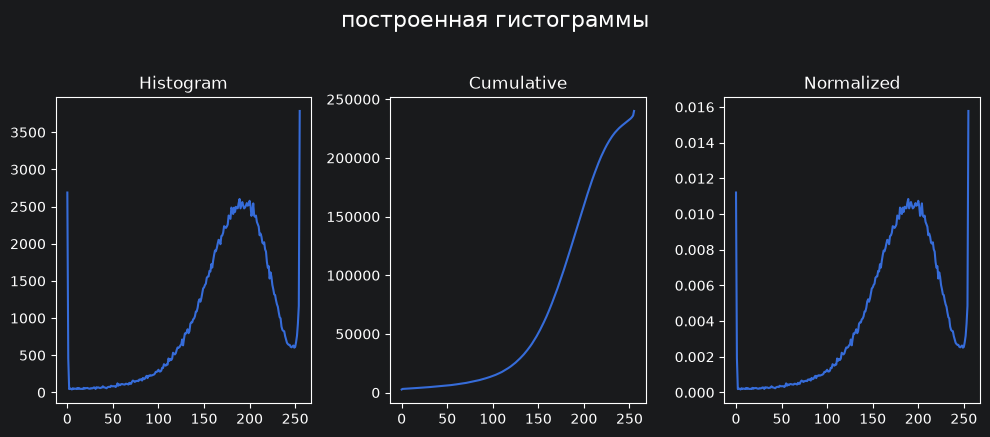

In [18]:
img_gray_u8 = (img_gray * 255).astype('uint8')
b_hist = cv2.calcHist([img_gray_u8], [0], None, [256], (0, 256), accumulate=False)
b_hist_cum = b_hist.cumsum()
b_hist_norm = b_hist / (img.shape[0] * img.shape[1])

hist_data = [
    (b_hist,      'Histogram'),
    (b_hist_cum,  'Cumulative'),
    (b_hist_norm, 'Normalized'),
]

fig = plt.figure(figsize=(10, 4.5))
fig.suptitle('построенная гистограммы', fontsize=16)
for idx, (data, title) in enumerate(hist_data, start=1):
    ax = fig.add_subplot(1, 3, idx)
    ax.set_title(title)
    ax.plot(data)
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
save_fig("histograms.png")
plt.show()

гамма-коррекция

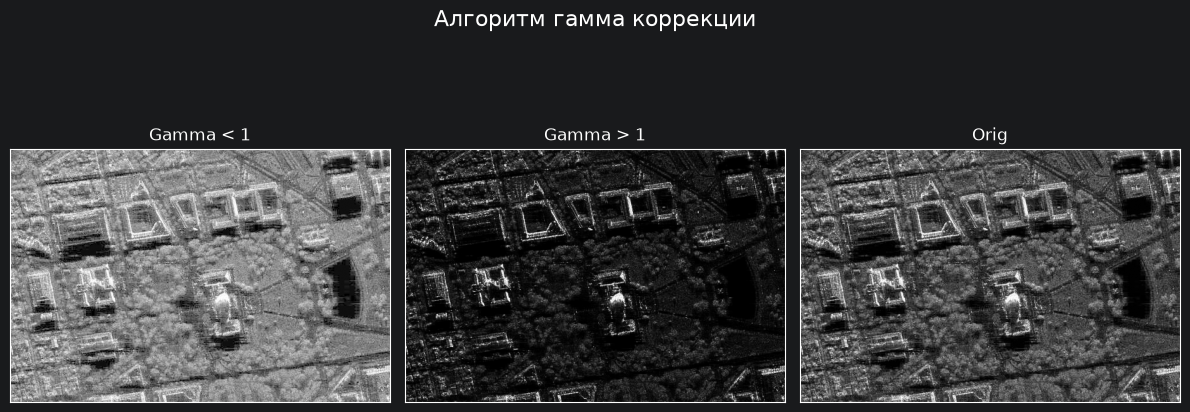

In [19]:
img_norm = img_gray.astype('float32')
img_norm = img_norm / img_norm.max()

def gamma_correction(img_, gamma):
    return np.power(img_, gamma)

gamma_low = 0.5
gamma_high = 2.0

img_gamma_low = gamma_correction(img_norm, gamma_low)
img_gamma_high = gamma_correction(img_norm, gamma_high)

img_gamma_low_8 = (img_gamma_low * 255.).astype('uint8')
img_gamma_high_8 = (img_gamma_high * 255.).astype('uint8')

gamma_pairs = [
    (img_gamma_low_8,  'Gamma < 1'),
    (img_gamma_high_8, 'Gamma > 1'),
    (img_gray,         'Orig'),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('Алгоритм гамма коррекции', fontsize=16)
for ax, (im, title) in zip(axes, gamma_pairs):
    ax.set_title(title)
    ax.imshow(im, cmap='gray')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
save_fig("gamma.png")
plt.show()

MSE, SSIM


Gamma < 1 (0.5)
SSIM: 0.7875009063454547
Gamma > 1 (2)
SSIM: 0.5270459697188647
MSE low: 0.04998737992360405
MSE high: 0.03665918959997279


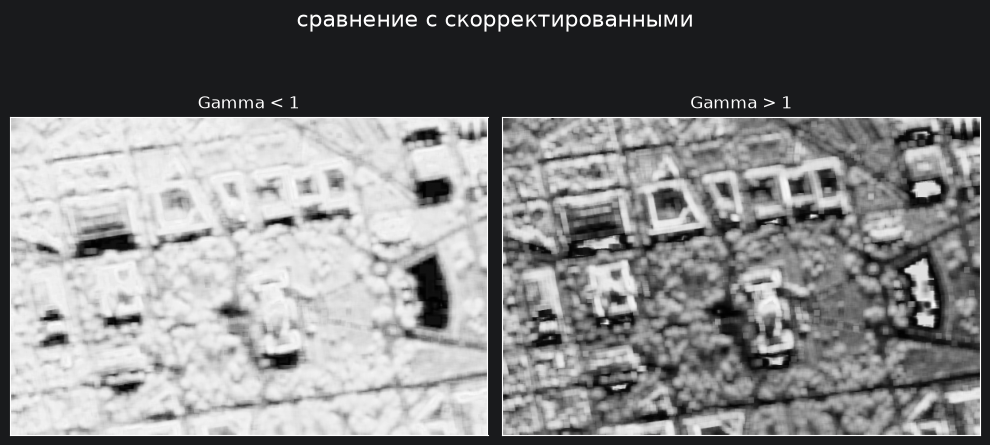

In [20]:
img_gray_f = img_gray.astype('float32')
img_gray_f = img_gray_f / img_gray_f.max()
img_gamma_low_f = img_gamma_low_8.astype('float32') / 255.
img_gamma_high_f = img_gamma_high_8.astype('float32') / 255.

ssim_low,  diff_low  = structural_similarity(img_gray_f, img_gamma_low_f,  full=True, data_range=1.0)
ssim_high, diff_high = structural_similarity(img_gray_f, img_gamma_high_f, full=True, data_range=1.0)

diff_low_8  = (diff_low  * 255).astype("uint8")
diff_high_8 = (diff_high * 255).astype("uint8")

mse_low  = mean_squared_error(img_gray_f, img_gamma_low_f)
mse_high = mean_squared_error(img_gray_f, img_gamma_high_f)

print("Gamma < 1 (0.5)")
print("SSIM: {}".format(ssim_low))
print("Gamma > 1 (2)")
print("SSIM: {}".format(ssim_high))
print("MSE low: {}".format(mse_low))
print("MSE high: {}".format(mse_high))

cmp_pairs = [
    (diff_low_8,  'Gamma < 1'),
    (diff_high_8, 'Gamma > 1'),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('сравнение с скорректированными', fontsize=16)
for ax, (im, title) in zip(axes, cmp_pairs):
    ax.set_title(title)
    ax.imshow(im, cmap='gray')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
save_fig("comparison.png")
plt.show()

статистическая цветокоррекция

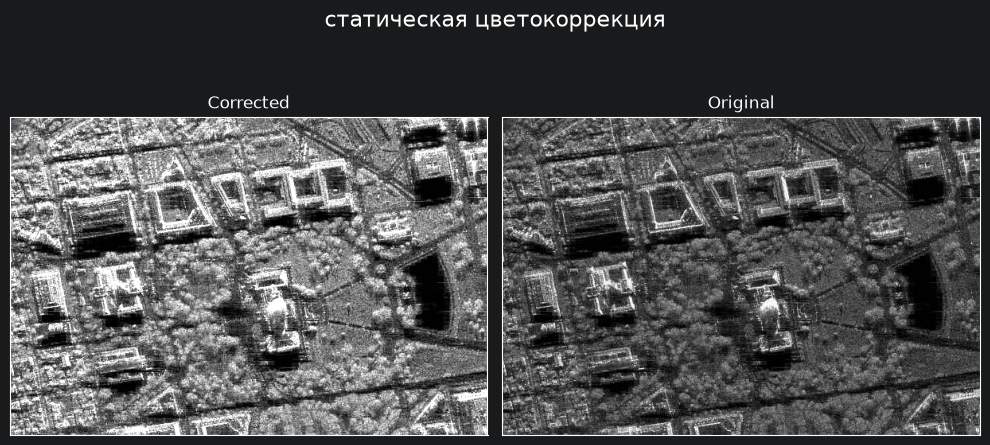

In [21]:
eq_gray = cv2.equalizeHist(img_gray.astype('uint8'))

src = img_gray.astype('float32'); src /= src.max()
eq  = eq_gray.astype('float32');  eq  /= eq.max()

mean_src, std_src = src.mean(), src.std()
mean_eq,  std_eq  = eq.mean(),  eq.std()

img_corr = (std_eq / std_src) * (src - mean_src) + mean_eq
img_corr = np.clip(img_corr, 0, 1)
img_corr_8 = (img_corr * 255).astype('uint8')

cc_pairs = [
    (img_corr_8, 'Corrected'),
    (img_gray,   'Original'),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('статическая цветокоррекция', fontsize=16)
for ax, (im, title) in zip(axes, cc_pairs):
    ax.set_title(title)
    ax.imshow(im, cmap='gray')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
save_fig("color_correction.png")
plt.show()

пороговая фильтрация

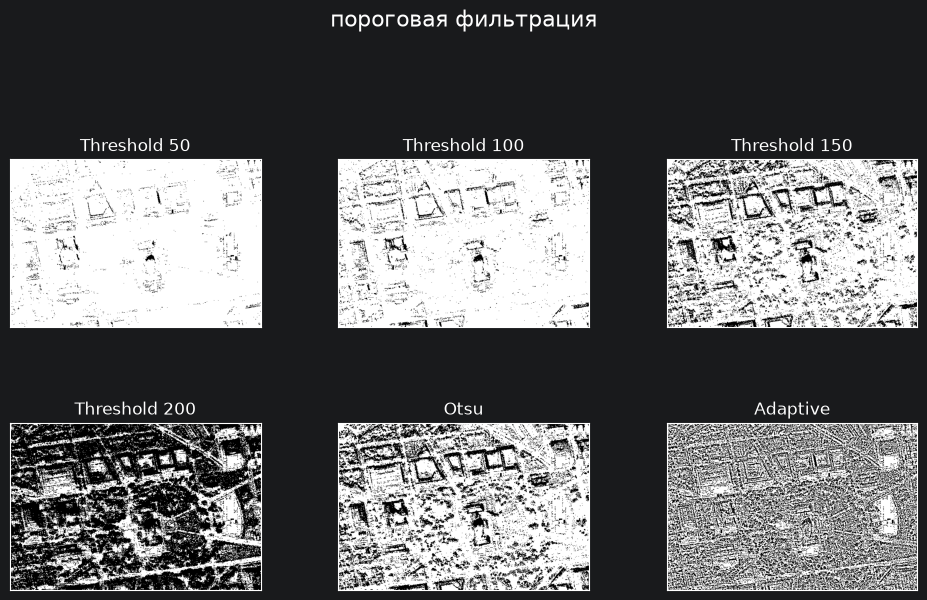

In [22]:
thresholds = [50, 100, 150, 200]
img_u8 = (img_gray * 255).astype('uint8')

_, th_otsu = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
th_adapt = cv2.adaptiveThreshold(
    img_u8, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11, 2)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
fig.suptitle('пороговая фильтрация', fontsize=16)

for i, T in enumerate(thresholds):
    _, thresh = cv2.threshold(img_u8, T, 255, cv2.THRESH_BINARY)
    ax = axes.ravel()[i]
    ax.set_title('Threshold {}'.format(T))
    ax.imshow(thresh, cmap='gray')
    ax.set_xticks([]); ax.set_yticks([])

axes[1, 1].set_title('Otsu')
axes[1, 1].imshow(th_otsu, cmap='gray')
axes[1, 1].set_xticks([]); axes[1, 1].set_yticks([])

axes[1, 2].set_title('Adaptive')
axes[1, 2].imshow(th_adapt, cmap='gray')
axes[1, 2].set_xticks([]); axes[1, 2].set_yticks([])

plt.tight_layout(rect=[0, 0.02, 1, 0.95])

k = 0.8
for ax in axes.ravel():
    pos = ax.get_position()
    w = pos.width  * k
    h = pos.height * k
    cx = pos.x0 + pos.width  / 2
    cy = pos.y0 + pos.height / 2
    ax.set_position([cx - w / 2, cy - h / 2, w, h])

save_fig("thresholds.png")
plt.show()